In [ ]:
# Reimporting libraries, data, filtering

import scanpy as sc
adata = sc.datasets.pbmc3k()
sc.settings.verbosity = 4
sc.settings.figdir = '../results/'

adata.var['mt'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

adata = adata[adata.obs.n_genes_by_counts > 200]
adata = adata[adata.obs.n_genes_by_counts < 2500]
adata = adata[adata.obs.pct_counts_mt < 5]
sc.pp.filter_genes(adata, min_cells=3)

filtered out 19082 genes that are detected in less than 3 cells


c:\Users\billn\.conda\envs\scrna\lib\site-packages\scanpy\preprocessing\_simple.py:293: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_cells"] = number


In [ ]:
# Normalization + log transformation
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

normalizing counts per cell
    finished (0:00:00)


extracting highly variable genes
    Gene indices [7822] fell into a single bin: their normalized dispersion was set to 1.
    Decreasing `n_bins` will likely avoid this effect.
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


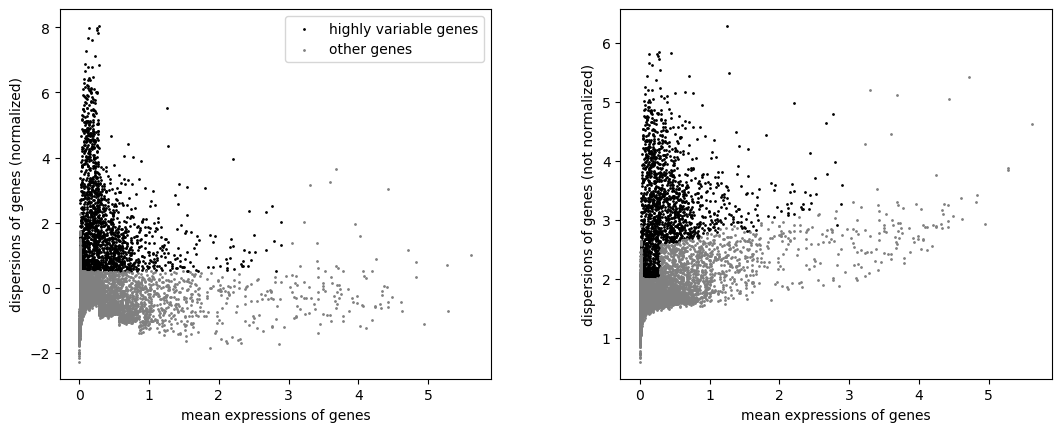

In [ ]:
# Identify highly variable genes
sc.pp.highly_variable_genes(
    adata,
    min_mean=0.0125,
    max_mean=3,
    min_disp=0.5
)

sc.pl.highly_variable_genes(adata)

In [ ]:
adata.raw = adata
adata = adata[:, adata.var.highly_variable]


In [ ]:
# Regress out effects of total counts per cell + percentage of MT genes expressed
sc.pp.regress_out(adata, ['total_counts', 'pct_counts_mt'])

# Scale each gene to unit variance. Clip values exceeding standard deviation 10.
sc.pp.scale(adata, max_value=10)

adata.write('../data/pbmc3k_preprocessed.h5ad')

regressing out ['total_counts', 'pct_counts_mt']
    sparse input is densified and may lead to high memory use
    finished (0:00:00)


c:\Users\billn\.conda\envs\scrna\lib\site-packages\scanpy\preprocessing\_simple.py:728: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
